In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import math, time
import itertools
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
import datetime
from operator import itemgetter
from sklearn.metrics import mean_squared_error
from math import sqrt
import torch
import torch.nn as nn
from torch.autograd import Variable
import os

In [13]:
os.chdir("//content//drive//MyDrive//Academy//AI_Specialist_Seft//LSTM//")
%pwd

'/content/drive/MyDrive/Academy/AI_Specialist_Seft/LSTM'

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
for dirname, _, filenames in os.walk('input'):
  print(dirname)
  print(filenames)

input
['aapl.us.txt', 'googl.us.txt', 'ibm.us.txt']


In [15]:
import os
for dirname, _, filenames in os.walk('input'):
    for i, filename in enumerate(filenames):
        if i<5:
            print(os.path.join(dirname,filename))

input/aapl.us.txt
input/googl.us.txt
input/ibm.us.txt


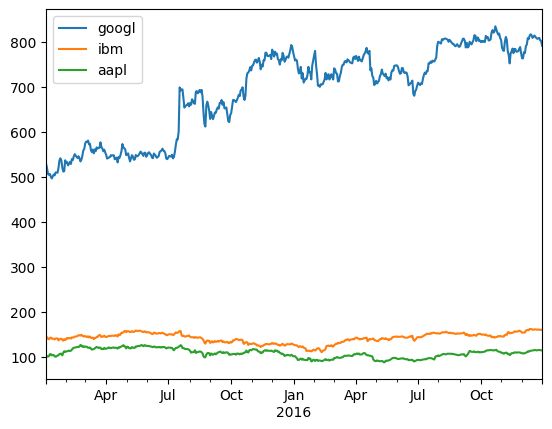

In [20]:
def stocks_data(symbols, dates):
    df = pd.DataFrame(index=dates)
    for symbol in symbols:
        df_temp = pd.read_csv("//content//drive//MyDrive//Academy//AI_Specialist_Seft//LSTM//{}.us.txt".format(symbol), index_col='Date',
                parse_dates=True, usecols=['Date', 'Close'], na_values=['nan'])
        df_temp = df_temp.rename(columns={'Close': symbol})
        df = df.join(df_temp)
    return df

dates = pd.date_range('2015-01-02','2016-12-31',freq='B')
symbols = ['googl','ibm','aapl']
df = stocks_data(symbols, dates)
df.fillna(method='pad')
df.interpolate().plot()
plt.show()

In [ ]:
df.head()

,googl,ibm,aapl
2015-01-02,529.55,145.54,103.50
2015-01-05,519.46,143.24,100.58
2015-01-06,506.64,140.14,100.59
2015-01-07,505.15,139.23,102.01
2015-01-08,506.91,142.26,105.93


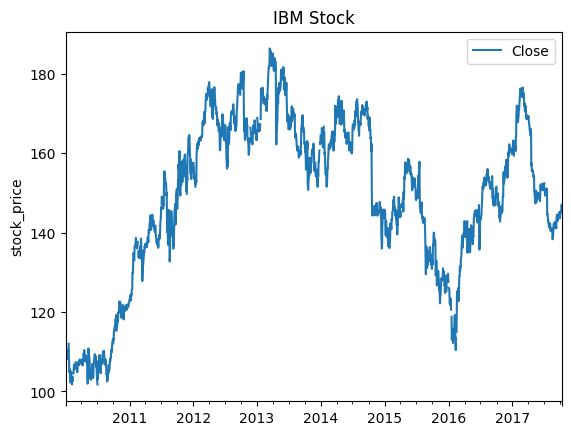

In [ ]:
dates = pd.date_range('2010-01-02','2017-10-11',freq='B')
df1=pd.DataFrame(index=dates)
df_ibm=pd.read_csv("/content/input/ibm.us.txt", parse_dates=True, index_col=0)
df_ibm=df1.join(df_ibm)
df_ibm[['Close']].plot()
plt.ylabel("stock_price")
plt.title("IBM Stock")
plt.show()

In [ ]:
df_ibm=df_ibm[['Close']]
df_ibm.describe()

,Close
count,1958.000000
mean,148.695112
std,20.453513
min,101.740000
25%,137.795000
50%,151.500000
75%,165.407500
max,186.360000


In [ ]:
df_ibm=df_ibm.fillna(method='ffill')

scaler = MinMaxScaler(feature_range=(-1, 1))
df_ibm['Close'] = scaler.fit_transform(df_ibm['Close'].values.reshape(-1,1))

In [ ]:
df_ibm.describe()

,Close
count,2028.000000
mean,0.109940
std,0.483132
min,-1.000000
25%,-0.147306
50%,0.177027
75%,0.504668
max,1.000000


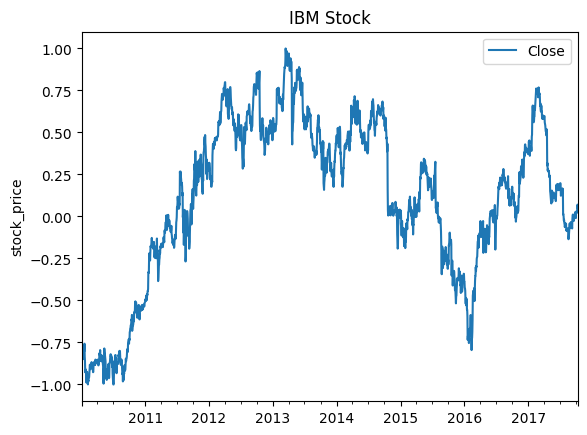

In [ ]:
df_ibm[['Close']].plot()
plt.ylabel("stock_price")
plt.title("IBM Stock")
plt.show()

In [ ]:
df_ibm.shape

(2028, 1)

In [ ]:
# function to create train, test data given stock data and sequence length
def load_data(stock, look_back):
    data_raw = stock.values # convert to numpy array
    print(data_raw.shape)

    data = []
    # create all possible sequences of length seq_len
    for index in range(len(data_raw) - look_back):
      # print(data_raw[index: index + look_back].shape)
      data.append(data_raw[index: index + look_back])

    data = np.array(data);
    print(data.shape)
    test_set_size = int(np.round(0.2*data.shape[0]));
    train_set_size = data.shape[0] - (test_set_size);

    print(data.shape)
    x_train = data[:train_set_size,:-1,:]
    y_train = data[:train_set_size,-1,:]

    x_test = data[train_set_size:,:-1]
    y_test = data[train_set_size:,-1,:]

    return [x_train, y_train, x_test, y_test]

look_back = 20 # choose sequence length
x_train, y_train, x_test, y_test = load_data(df_ibm, look_back)
print('x_train.shape = ',x_train.shape)
print('y_train.shape = ',y_train.shape)
print('x_test.shape = ',x_test.shape)
print('y_test.shape = ',y_test.shape)

(2028, 1)
(2008, 20, 1)
(2008, 20, 1)
x_train.shape =  (1606, 19, 1)
y_train.shape =  (1606, 1)
x_test.shape =  (402, 19, 1)
y_test.shape =  (402, 1)


In [ ]:
df_ibm[['Close']][18:25]

,Close
2010-01-28,-0.962420
2010-01-29,-0.988892
2010-02-01,-0.943985
2010-02-02,-0.927440
2010-02-03,-0.924840
2010-02-04,-0.977310
2010-02-05,-0.966675


In [ ]:
# make training and test sets in torch
x_train = torch.from_numpy(x_train).type(torch.Tensor)
x_test = torch.from_numpy(x_test).type(torch.Tensor)
y_train = torch.from_numpy(y_train).type(torch.Tensor)
y_test = torch.from_numpy(y_test).type(torch.Tensor)

In [ ]:
y_train.size(),x_train.size()

(torch.Size([1606, 1]), torch.Size([1606, 19, 1]))

In [ ]:
print(x_train[0])
print(y_train)

tensor([[-0.7908],
        [-0.8223],
        [-0.8388],
        [-0.8476],
        [-0.8223],
        [-0.8492],
        [-0.8294],
        [-0.8341],
        [-0.7934],
        [-0.8036],
        [-0.8036],
        [-0.7573],
        [-0.8338],
        [-0.8589],
        [-0.9277],
        [-0.9152],
        [-0.9227],
        [-0.9111],
        [-0.9624]])
tensor([[-0.9889],
        [-0.9440],
        [-0.9274],
        ...,
        [-0.1851],
        [-0.1288],
        [-0.1288]])


In [ ]:
n_steps = look_back-1
batch_size = 1606
#n_iters = 3000
num_epochs = 100 #n_iters / (len(train_X) / batch_size)
#num_epochs = int(num_epochs)

train = torch.utils.data.TensorDataset(x_train,y_train)
test = torch.utils.data.TensorDataset(x_test,y_test)

train_loader = torch.utils.data.DataLoader(dataset=train,
                                           batch_size=batch_size,
                                           shuffle=False)

test_loader = torch.utils.data.DataLoader(dataset=test,
                                          batch_size=batch_size,
                                          shuffle=False)

In [ ]:
# Build model
#####################
input_dim = 1
hidden_dim = 32
num_layers = 2
output_dim = 1

# Here we define our model as a class
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTM, self).__init__()
        # Hidden dimensions
        self.hidden_dim = hidden_dim

        # Number of hidden layers
        self.num_layers = num_layers

        # Building your LSTM
        # batch_first=True causes input/output tensors to be of shape
        # (batch_dim, seq_dim, feature_dim)
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)

        # Readout layer
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()

        # Initialize cell state
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()

        # One time step
        # We need to detach as we are doing truncated backpropagation through time (BPTT)
        # If we don't, we'll backprop all the way to the start even after going through another batch
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))

        # Index hidden state of last time step
        # out.size() --> 32, 28, 100
        # out[:, -1, :] --> 32, 100 --> just want last time step hidden states!
        out = self.fc(out[:, -1, :])
        # out.size() --> 100, 10
        return out

In [ ]:
model = LSTM(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)

In [ ]:
loss_fn = torch.nn.MSELoss(reduction='mean')

optimiser = torch.optim.Adam(model.parameters(), lr=0.01)
print(model)
print(len(list(model.parameters())))
for i in range(len(list(model.parameters()))):
    print(list(model.parameters())[i].size())

LSTM(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
10
torch.Size([128, 1])
torch.Size([128, 32])
torch.Size([128])
torch.Size([128])
torch.Size([128, 32])
torch.Size([128, 32])
torch.Size([128])
torch.Size([128])
torch.Size([1, 32])
torch.Size([1])


In [ ]:
x_train.size()

torch.Size([1606, 19, 1])

In [ ]:
# Train model
#####################

hist = np.zeros(num_epochs)

# Number of steps to unroll
seq_dim =look_back-1

for t in range(num_epochs):
    # Initialise hidden state
    # Don't do this if you want your LSTM to be stateful
    #model.hidden = model.init_hidden()

    # Forward pass
    y_train_pred = model(x_train)

    loss = loss_fn(y_train_pred, y_train)
    if t % 10 == 0 and t !=0:
        print("Epoch ", t, "MSE: ", loss.item())
    hist[t] = loss.item()

    # Zero out gradient, else they will accumulate between epochs
    optimiser.zero_grad()

    # Backward pass
    loss.backward()

    # Update parameters
    optimiser.step()

Epoch  10 MSE:  0.02613944374024868
Epoch  20 MSE:  0.015085111372172832
Epoch  30 MSE:  0.008180996403098106
Epoch  40 MSE:  0.007568090222775936
Epoch  50 MSE:  0.005340819247066975
Epoch  60 MSE:  0.004623489920049906
Epoch  70 MSE:  0.004248129669576883
Epoch  80 MSE:  0.0038984278216958046
Epoch  90 MSE:  0.0036365946289151907


In [ ]:
y_train.detach().numpy()

array([[-0.98889154],
       [-0.94398487],
       [-0.92744035],
       ...,
       [-0.18506263],
       [-0.12881115],
       [-0.12881115]], dtype=float32)

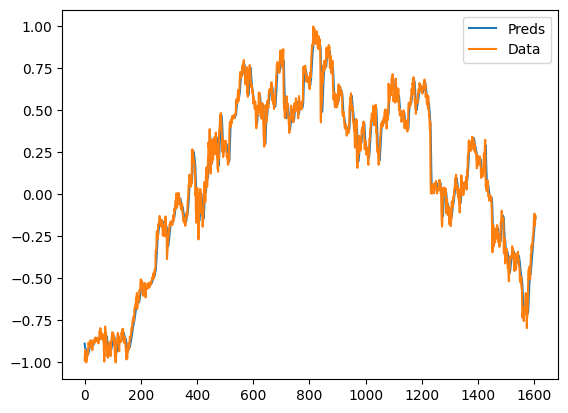

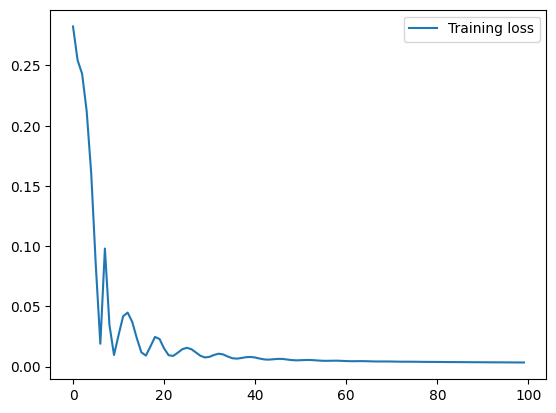

In [ ]:
plt.plot(y_train_pred.detach().numpy(), label="Preds")
plt.plot(y_train.detach().numpy(), label="Data")
plt.legend()
plt.show()

plt.plot(hist, label="Training loss")
plt.legend()
plt.show()

In [ ]:
np.shape(y_train_pred)

torch.Size([1606, 1])

In [ ]:
# make predictions
y_test_pred = model(x_test)

# invert predictions
y_train_pred = scaler.inverse_transform(y_train_pred.detach().numpy())
y_train = scaler.inverse_transform(y_train.detach().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().numpy())
y_test = scaler.inverse_transform(y_test.detach().numpy())

# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(y_train[:,0], y_train_pred[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(y_test[:,0], y_test_pred[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

Train Score: 2.49 RMSE
Test Score: 1.91 RMSE


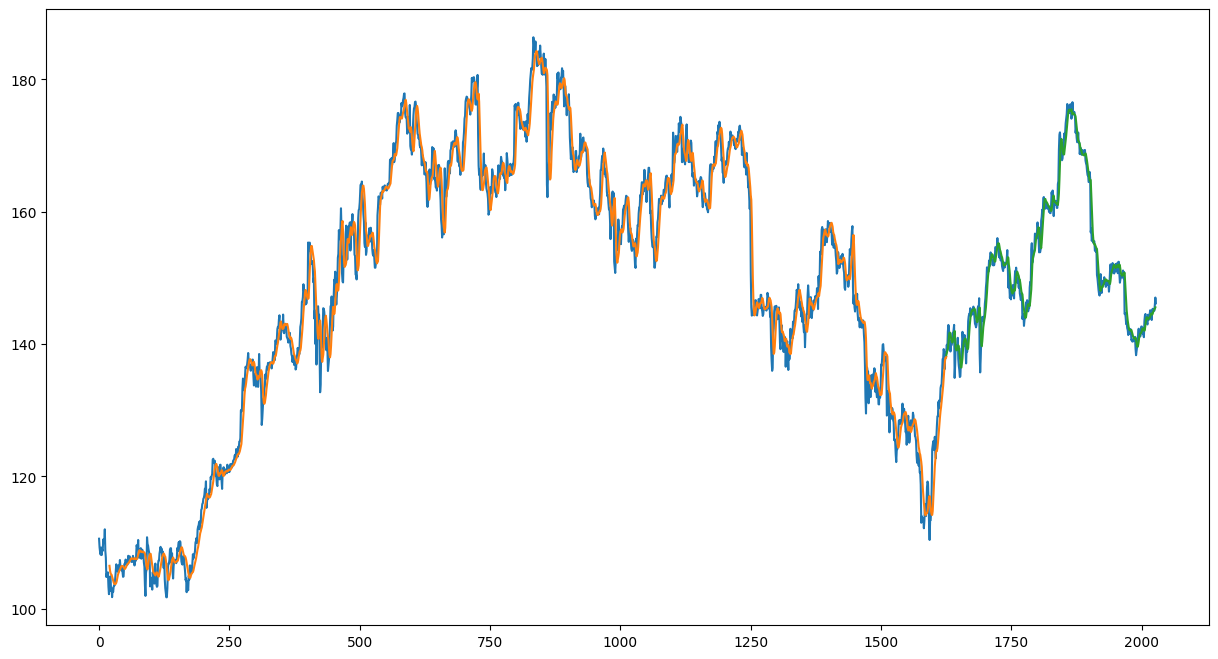

In [ ]:
# shift train predictions for plotting
trainPredictPlot = np.empty_like(df_ibm)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(y_train_pred)+look_back, :] = y_train_pred

# shift test predictions for plotting
testPredictPlot = np.empty_like(df_ibm)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(y_train_pred)+look_back-1:len(df_ibm)-1, :] = y_test_pred

# plot baseline and predictions
plt.figure(figsize=(15,8))
plt.plot(scaler.inverse_transform(df_ibm))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()